In [ ]:
# Bayesian Optimization mit globalen Nullmodellen aus Ordner mit counter
# Sucht nach der besten Parameterkombination für die Proximity-Funktion
# unter Verwendung von Bayesian Optimization.

# ================================
# Imports
# ================================
import os
import numpy as np
import pandas as pd
from skopt import gp_minimize
from skopt.space import Real, Integer
import matplotlib.pyplot as plt
import seaborn as sns
import time

# ================================
# Proximity-Funktion
# ================================

def proximity_max_freq(
    x,
    sharpness_base=10.0,
    sharpness_growth=2.0,
    decay=0.1,
    max_freq=4,
    weight_exponent=1.0,
    freq_sharpness_exp=1.0,
    norm_x=1.0,
    output_max=1.0
):
    x = np.array(x)
    freqs = np.arange(1, max_freq + 1)
    all_freq_values = []

    for freq in freqs:
        weight = 1.0 / (freq ** weight_exponent)
        freq_sharpness_base = sharpness_base * (freq ** freq_sharpness_exp)
        freq_sharpness_growth = sharpness_growth * (freq ** freq_sharpness_exp)

        sharpness = freq_sharpness_base * (x ** freq_sharpness_growth)
        cos_term = ((1 + np.cos(2 * np.pi * freq * x)) / 2) ** sharpness

        peak_sharpness = freq_sharpness_base * (norm_x ** freq_sharpness_growth)
        peak_value = ((1 + np.cos(2 * np.pi * freq * norm_x)) / 2) ** peak_sharpness
        peak_value = np.where(peak_value == 0, 1e-12, peak_value)

        denom = np.where(x == 0, 1e-12, x ** decay)
        val = weight * (cos_term / peak_value) / denom
        all_freq_values.append(val)

    all_freq_values = np.array(all_freq_values)
    proximity_max = np.max(all_freq_values, axis=0)

    max_at_norm_x = np.max([
        (1.0 / (freq ** weight_exponent)) * 1.0 / (norm_x ** decay)
        for freq in freqs
    ])
    proximity_max = proximity_max / max_at_norm_x * output_max
    return proximity_max

# ================================
# Folder-Analyse
# ================================
_already_printed_global_ioi = False

def analyze_folder_global_null(folder_path, params, num_sequences=500, seed=42):
    global _already_printed_global_ioi
    rng = np.random.default_rng(seed)
    results_list = []

    # -----------------------------
    # 1) Alle IOIs laden und globale Parameter bestimmen
    # -----------------------------
    all_iois = []
    seqs = []

    for fname in os.listdir(folder_path):
        if not fname.endswith(".csv"):
            continue

        df = pd.read_csv(os.path.join(folder_path, fname))
        if "IOI" not in df.columns:
            continue

        iois = df["IOI"].dropna().values
        if len(iois) < 3:
            continue

        all_iois.extend(iois)
        seqs.append((fname, iois))

    all_iois = np.array(all_iois)
    global_median_ioi = np.median(all_iois)
    global_min = np.percentile(all_iois, 5)
    global_max = np.percentile(all_iois, 95)

    # nur beim allerersten Funktionsaufruf ausgeben
    if not _already_printed_global_ioi:
        print(f"Global median IOI = {global_median_ioi:.3f}")
        print(f"Uniform bounds = [{global_min:.3f}, {global_max:.3f}]")
        _already_printed_global_ioi = True
    
        # -----------------------------
    # 2) Nullmodelle vorbereiten (pro Sequenz-Länge!)
    # -----------------------------
    null_cache_expon = {}
    null_cache_uniform = {}
    null_cache_empirical = {}

    for fname, iois in seqs:
        n = len(iois)

        # Exponential Null
        if n not in null_cache_expon:
            medians_expon = []
            for _ in range(num_sequences):
                sim_iois = rng.exponential(scale=global_median_ioi, size=n)
                ratios = np.array([[max(sim_iois[i], sim_iois[j]) / min(sim_iois[i], sim_iois[j])
                                    for j in range(n)] for i in range(n)])
                prox_mat = proximity_max_freq(ratios, **params)
                triu_idx = np.triu_indices_from(prox_mat, k=1)
                medians_expon.append(np.median(prox_mat[triu_idx]))
            null_cache_expon[n] = np.array(medians_expon)

        # Uniform Null
        if n not in null_cache_uniform:
            medians_uniform = []
            for _ in range(num_sequences):
                sim_iois = rng.uniform(global_min, global_max, size=n)
                ratios = np.array([[max(sim_iois[i], sim_iois[j]) / min(sim_iois[i], sim_iois[j])
                                    for j in range(n)] for i in range(n)])
                prox_mat = proximity_max_freq(ratios, **params)
                triu_idx = np.triu_indices_from(prox_mat, k=1)
                medians_uniform.append(np.median(prox_mat[triu_idx]))
            null_cache_uniform[n] = np.array(medians_uniform)

        # Empirical Null (zieht zufällig IOIs aus ALLEN IOIs des Ordners)
        if n not in null_cache_empirical:
            medians_empirical = []
            for _ in range(num_sequences):
                sim_iois = rng.choice(all_iois, size=n, replace=True)
                ratios = np.array([[max(sim_iois[i], sim_iois[j]) / min(sim_iois[i], sim_iois[j])
                                    for j in range(n)] for i in range(n)])
                prox_mat = proximity_max_freq(ratios, **params)
                triu_idx = np.triu_indices_from(prox_mat, k=1)
                medians_empirical.append(np.median(prox_mat[triu_idx]))
            null_cache_empirical[n] = np.array(medians_empirical)

    # -----------------------------
    # 3) Analyse jeder Sequenz mit den globalen Nullmodellen
    # -----------------------------
    for fname, iois in seqs:
        n = len(iois)
        ratios_real = np.array([[max(iois[i], iois[j]) / min(iois[i], iois[j])
                                 for j in range(n)] for i in range(n)])
        prox_mat_real = proximity_max_freq(ratios_real, **params)
        triu_idx = np.triu_indices_from(prox_mat_real, k=1)
        proximity_real = prox_mat_real[triu_idx]
        median_real = np.median(proximity_real)

        # Exponential
        medians_expon = null_cache_expon[n]
        mean_expon = np.mean(medians_expon)
        std_expon = np.std(medians_expon, ddof=1)
        zscore_expon = (median_real - mean_expon) / std_expon if std_expon > 0 else np.nan
        pval_expon = (np.sum(medians_expon >= median_real) + 1) / (len(medians_expon) + 1)

        # Uniform
        medians_uniform = null_cache_uniform[n]
        mean_uniform = np.mean(medians_uniform)
        std_uniform = np.std(medians_uniform, ddof=1)
        zscore_uniform = (median_real - mean_uniform) / std_uniform if std_uniform > 0 else np.nan
        pval_uniform = (np.sum(medians_uniform >= median_real) + 1) / (len(medians_uniform) + 1)

        # Empirical
        medians_empirical = null_cache_empirical[n]
        mean_empirical = np.mean(medians_empirical)
        std_empirical = np.std(medians_empirical, ddof=1)
        zscore_empirical = (median_real - mean_empirical) / std_empirical if std_empirical > 0 else np.nan
        pval_empirical = (np.sum(medians_empirical >= median_real) + 1) / (len(medians_empirical) + 1)

        results_list.append({
            "filename": fname,
            "real_median": median_real,
            "expon_mean": mean_expon,
            "expon_std": std_expon,
            "uniform_mean": mean_uniform,
            "uniform_std": std_uniform,
            "empirical_mean": mean_empirical,   
            "empirical_std": std_empirical,     
            "diff_real_expon": median_real - mean_expon,
            "diff_real_uniform": median_real - mean_uniform,
            "diff_real_empirical": median_real - mean_empirical,   
            "zscore_expon": zscore_expon,
            "pval_expon": pval_expon,
            "zscore_uniform": zscore_uniform,
            "pval_uniform": pval_uniform,
            "zscore_empirical": zscore_empirical,   
            "pval_empirical": pval_empirical        
        })


    return pd.DataFrame(results_list)

# ================================
# Bayesian Optimization
# ================================

def bayesian_search_global_null(
    folder_path,
    n_calls=100,
    num_sequences=500,
    seed=42,
    objective="zscore",   # one of: "diff", "zscore", "pval"
    null_model="expon",   # name used in analyze_folder columns for now: "expon", "uniform", "empirical"
    param_space_def=None   # optional: override default param space dictionary (same keys as before)
):
    """
    Bayesian search over the proximity-function parameter space.
    objective: "diff" (max), "zscore" (max), "pval" (min)
    null_model: string used to select columns returned by analyze_folder, e.g. "expon" -> diff_real_expon, zscore_expon, pval_expon
    Returns: summary_df (all evaluated params saved), best_params (according to chosen objective)
    """

    rng = np.random.default_rng(seed)
    default_params = {"norm_x": 1.0, "output_max": 1.0}

    # default parameter-space (same ranges as before)
    if param_space_def is None:
        param_space_def = {
            "sharpness_base": (1.0, 50.0),
            "sharpness_growth": (0.0, 5.0),
            "decay": (0.0, 4.0),
            "max_freq": (1, 6),  # integer
            "weight_exponent": (0.0, 4.0),
            "freq_sharpness_exp": (0.0, 4.0)
        }

    # build skopt space
    sk_space = [
        Real(param_space_def["sharpness_base"][0], param_space_def["sharpness_base"][1], name="sharpness_base"),
        Real(param_space_def["sharpness_growth"][0], param_space_def["sharpness_growth"][1], name="sharpness_growth"),
        Real(param_space_def["decay"][0], param_space_def["decay"][1], name="decay"),
        Integer(param_space_def["max_freq"][0], param_space_def["max_freq"][1], name="max_freq"),
        Real(param_space_def["weight_exponent"][0], param_space_def["weight_exponent"][1], name="weight_exponent"),
        Real(param_space_def["freq_sharpness_exp"][0], param_space_def["freq_sharpness_exp"][1], name="freq_sharpness_exp"),
    ]

    # will store intermediate results for post-hoc analysis
    eval_records = []
    call_counter = {"n": 0}
    timing_info = {"start": None}

    # objective function for gp_minimize (we minimize)
    def objective_func(x):
        call_counter["n"] += 1

        # Startzeit merken
        if timing_info["start"] is None:
            timing_info["start"] = time.time()

        # vergangene Zeit berechnen
        elapsed = time.time() - timing_info["start"]
        avg_time = elapsed / call_counter["n"]
        remaining = avg_time * (n_calls - call_counter["n"])
        eta_min = int(remaining // 60)
        eta_sec = int(remaining % 60)

        print(f"[Bayesian Optimization] Iteration {call_counter['n']} / {n_calls} "
            f"(ETA: {eta_min}m {eta_sec}s)")

        # map x to param dict
        names = ["sharpness_base", "sharpness_growth", "decay", "max_freq",
                "weight_exponent", "freq_sharpness_exp"]
        params = default_params.copy()
        params.update({n: v for n, v in zip(names, x)})
        params["max_freq"] = int(round(params["max_freq"]))

        # run analysis (this is the expensive call)
        results_df = analyze_folder_global_null(folder_path, params,
                                                num_sequences=num_sequences, seed=seed)

        if results_df.empty:
            return 1e6

        col_map = {
            "diff": f"diff_real_{null_model}",
            "zscore": f"zscore_{null_model}",
            "pval": f"pval_{null_model}"
        }
        col = col_map[objective]
        if col not in results_df.columns:
            return 1e5

        vals = results_df[col].dropna().values
        if len(vals) == 0:
            return 1e5

        if objective in ("diff", "zscore"):
            agg = np.median(vals)
            score = -float(agg)
        else:  # pval
            agg = np.median(vals)
            score = float(agg)

        eval_records.append({**params, f"agg_{objective}_{null_model}": float(agg)})

        return score

    # run Bayesian optimization
    res = gp_minimize(objective_func, sk_space, n_calls=n_calls, random_state=seed)

    # collect evaluated params into DataFrame
    summary_eval_df = pd.DataFrame(eval_records)

    # determine best set according to chosen objective
    agg_col_name = f"agg_{objective}_{null_model}"
    if agg_col_name in summary_eval_df.columns and not summary_eval_df.empty:
        if objective in ("diff", "zscore"):
            best_idx = summary_eval_df[agg_col_name].idxmax()
        else:  # pval
            best_idx = summary_eval_df[agg_col_name].idxmin()
        best_row = summary_eval_df.loc[best_idx]
    else:
        best_row = None

    return summary_eval_df, best_row, res

# ================================
# Aufruf der Bayesian Search mit Parameter-Logging
# ================================

# Warnungen für Überlauf (overflow) ignorieren
np.seterr(over='ignore', divide='warn', invalid='warn')

folder_path = "/Users/emilschmiedl/Desktop/Proximity-Funktion/data/Sperm whale Physeter macrocephalus (sw)"

# Parameter für bayesian_search_global_null
n_calls = 60
num_sequences = 100
seed = 42
objective = "pval"   # Ziele: "diff", "zscore" oder "pval"
null_model = "empirical"   # Nullmodelle: "expon", "uniform", "empirical"
param_space_def = None  # optional

# Parameter ausgeben
print("=== Bayesian Search Konfiguration ===")
print(f"Folder path: {folder_path}")
print(f"n_calls: {n_calls}")
print(f"num_sequences: {num_sequences}")
print(f"seed: {seed}")
print(f"objective: {objective}")
print(f"null_model: {null_model}")
print("=====================================")

# ================================
# Bayesian Search ausführen
# ================================
summary_eval_df, best_row, res = bayesian_search_global_null(
    folder_path=folder_path,
    n_calls=n_calls,
    num_sequences=num_sequences,
    seed=seed,
    objective=objective,
    null_model=null_model,
    param_space_def=param_space_def
)

# Ergebnisse in DataFrame
results_df = summary_eval_df.copy()

# Top 10 Ergebnisse nach Zielwert
print("\nTop 10 Ergebnisse der Bayesian Optimization:")
print(results_df.sort_values(by=results_df.columns[-1], ascending=False).head(10))

# Verlauf der Zielwerte über Iterationen
plt.figure(figsize=(10, 5))
plt.plot(results_df[results_df.columns[-1]].values, marker='o')
plt.title(f'Verlauf der Zielwerte über Iterationen\nObjective = {objective}, Null-Modell = {null_model}')
plt.xlabel('Iteration')
plt.ylabel(f'Zielwert ({objective}_{null_model})')
plt.grid(True)
plt.show()

# Histogramm der Zielwerte
plt.figure(figsize=(8, 4))
sns.histplot(results_df[results_df.columns[-1]], bins=15, kde=True)
plt.title(f'Verteilung der Zielwerte\nObjective = {objective}, Null-Modell = {null_model}')
plt.xlabel(f'Zielwert ({objective}_{null_model})')
plt.ylabel('Häufigkeit')
plt.show()

# Pairplot für Parameter vs. Zielwert
param_cols = ["sharpness_base","sharpness_growth","decay","max_freq","weight_exponent","freq_sharpness_exp"]

if len(param_cols) <= 6:
    sns.pairplot(
        results_df,
        vars=param_cols,
        hue=results_df.columns[-1],
        palette='viridis',
        height=2.5
    )
    plt.suptitle(f'Parameter-Paarungen vs Zielwert\nObjective = {objective}, Null-Modell = {null_model}', y=1.02)
    plt.show()

# Beste Parameterkombination
print("\nBeste Parameterkombination:")
print(best_row[param_cols])

# Optional: Export als CSV mit Parametern im Dateinamen
filename = f"bayesian_search_results_{objective}_{null_model}_n{n_calls}_seq{num_sequences}_seed{seed}.csv"
results_df.to_csv(filename, index=False)
print(f"Ergebnisse wurden als '{filename}' gespeichert.")

=== Bayesian Search Konfiguration ===
Folder path: /Users/emilschmiedl/Desktop/Proximity-Funktion/data/Sperm whale Physeter macrocephalus (sw)
n_calls: 60
num_sequences: 100
seed: 42
objective: pval
null_model: empirical
[Bayesian Optimization] Iteration 1 / 60 (ETA: 0m 0s)
Global median IOI = 0.446
Uniform bounds = [0.388, 0.634]
[Bayesian Optimization] Iteration 2 / 60 (ETA: 196m 48s)
[Bayesian Optimization] Iteration 3 / 60 (ETA: 354m 38s)
[Bayesian Optimization] Iteration 4 / 60 (ETA: 354m 46s)
[Bayesian Optimization] Iteration 5 / 60 (ETA: 338m 57s)


Starte Optimierung: Folder=/Users/emilschmiedl/Desktop/Proximity-Funktion/data/Kwa-Sounds Scorpaena spp, Nullmodell=expon, Objective=pval
[Bayesian Optimization] Iteration 1 / 50 (ETA: 0m 0s)
Global median IOI = 1.626
Uniform bounds = [0.257, 3.472]
[Bayesian Optimization] Iteration 2 / 50 (ETA: 1m 21s)


/var/folders/3q/_wl3lf3179gcd3z2kdgr6g940000gn/T/ipykernel_4006/759819799.py:43: RuntimeWarning: overflow encountered in power
  sharpness = freq_sharpness_base * (x ** freq_sharpness_growth)
/var/folders/3q/_wl3lf3179gcd3z2kdgr6g940000gn/T/ipykernel_4006/759819799.py:43: RuntimeWarning: overflow encountered in multiply
  sharpness = freq_sharpness_base * (x ** freq_sharpness_growth)


[Bayesian Optimization] Iteration 3 / 50 (ETA: 1m 42s)
[Bayesian Optimization] Iteration 4 / 50 (ETA: 1m 48s)
[Bayesian Optimization] Iteration 5 / 50 (ETA: 1m 42s)


/var/folders/3q/_wl3lf3179gcd3z2kdgr6g940000gn/T/ipykernel_4006/759819799.py:43: RuntimeWarning: overflow encountered in power
  sharpness = freq_sharpness_base * (x ** freq_sharpness_growth)
/var/folders/3q/_wl3lf3179gcd3z2kdgr6g940000gn/T/ipykernel_4006/759819799.py:43: RuntimeWarning: overflow encountered in multiply
  sharpness = freq_sharpness_base * (x ** freq_sharpness_growth)


[Bayesian Optimization] Iteration 6 / 50 (ETA: 1m 49s)
[Bayesian Optimization] Iteration 7 / 50 (ETA: 1m 52s)


...

/var/folders/3q/_wl3lf3179gcd3z2kdgr6g940000gn/T/ipykernel_4006/759819799.py:43: RuntimeWarning: overflow encountered in power
  sharpness = freq_sharpness_base * (x ** freq_sharpness_growth)
/var/folders/3q/_wl3lf3179gcd3z2kdgr6g940000gn/T/ipykernel_4006/759819799.py:43: RuntimeWarning: overflow encountered in multiply
  sharpness = freq_sharpness_base * (x ** freq_sharpness_growth)


[Bayesian Optimization] Iteration 48 / 50 (ETA: 0m 5s)


/var/folders/3q/_wl3lf3179gcd3z2kdgr6g940000gn/T/ipykernel_4006/759819799.py:43: RuntimeWarning: overflow encountered in power
  sharpness = freq_sharpness_base * (x ** freq_sharpness_growth)
/var/folders/3q/_wl3lf3179gcd3z2kdgr6g940000gn/T/ipykernel_4006/759819799.py:43: RuntimeWarning: overflow encountered in multiply
  sharpness = freq_sharpness_base * (x ** freq_sharpness_growth)


[Bayesian Optimization] Iteration 49 / 50 (ETA: 0m 2s)
[Bayesian Optimization] Iteration 50 / 50 (ETA: 0m 0s)
Beste Parameterkombination:
{'sharpness_base': np.float64(17.676183999384367), 'sharpness_growth': np.float64(5.0), 'decay': np.float64(4.0), 'max_freq': np.float64(6.0), 'weight_exponent': np.float64(1.084535113202699), 'freq_sharpness_exp': np.float64(1.7047619498847528), 'norm_x': 1.0, 'output_max': 1.0}


/var/folders/3q/_wl3lf3179gcd3z2kdgr6g940000gn/T/ipykernel_4006/759819799.py:43: RuntimeWarning: overflow encountered in power
  sharpness = freq_sharpness_base * (x ** freq_sharpness_growth)
/var/folders/3q/_wl3lf3179gcd3z2kdgr6g940000gn/T/ipykernel_4006/759819799.py:43: RuntimeWarning: overflow encountered in multiply
  sharpness = freq_sharpness_base * (x ** freq_sharpness_growth)


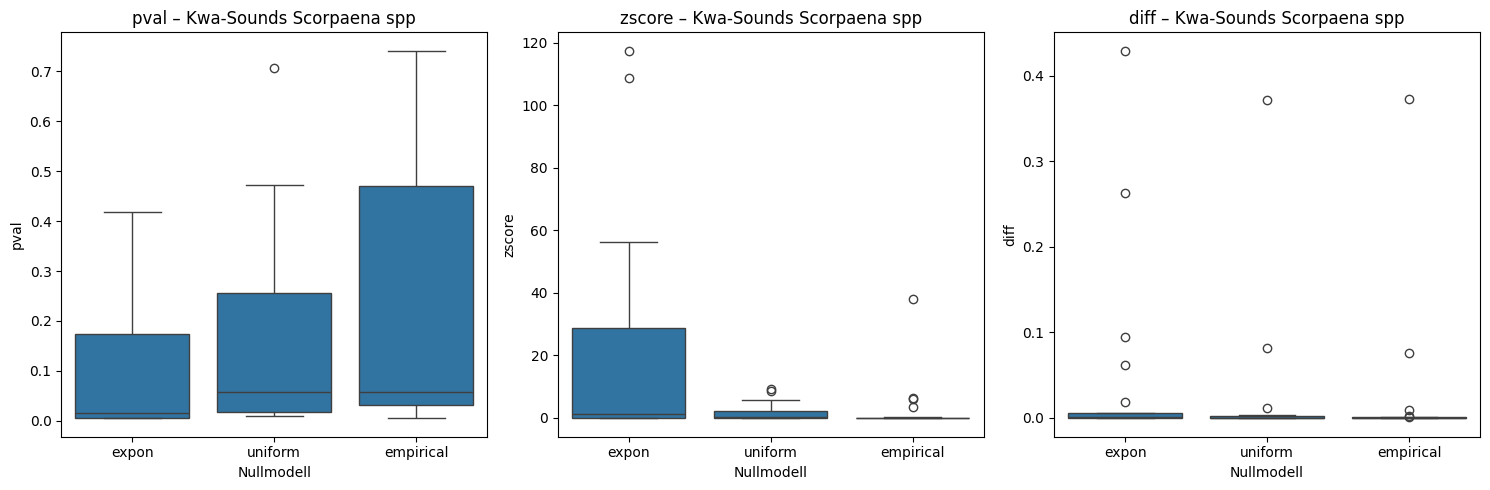

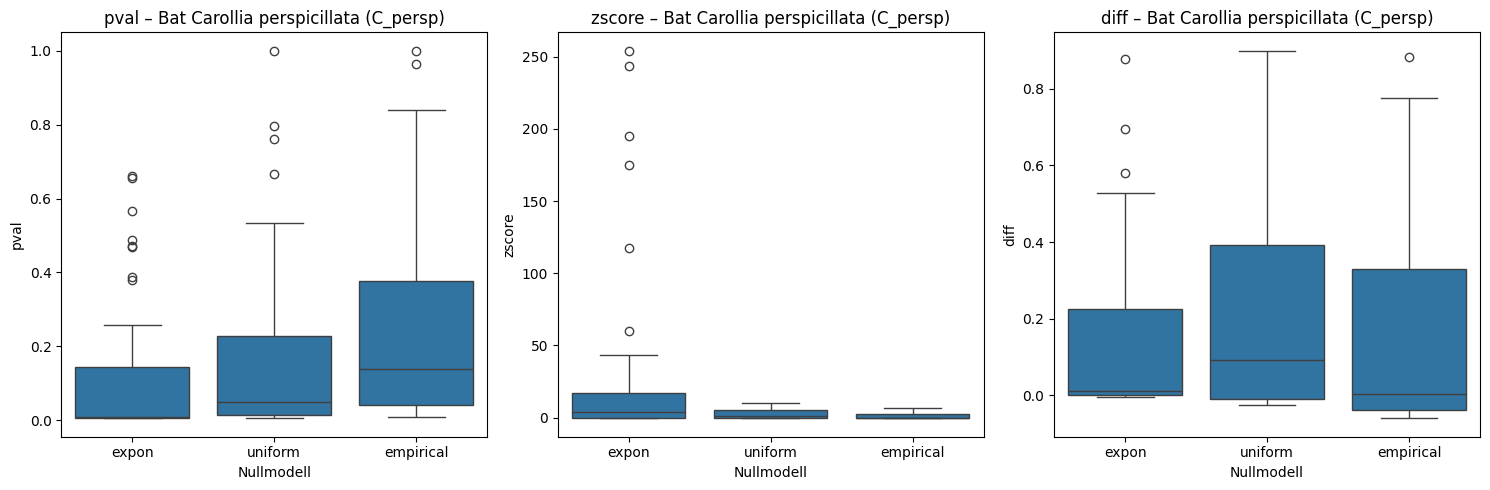

Sequenz-Level-Ergebnisse in 'seq_level_results.csv' gespeichert.


In [7]:
# testtttt

# Bayesian Optimization mit globalen Nullmodellen aus Ordner mit counter
# Sucht nach der besten Parameterkombination für die Proximity-Funktion
# unter Verwendung von Bayesian Optimization.

# ================================
# Imports
# ================================
import os
import numpy as np
import pandas as pd
from skopt import gp_minimize
from skopt.space import Real, Integer
import matplotlib.pyplot as plt
import seaborn as sns
import time

# ================================
# Proximity-Funktion
# ================================

def proximity_max_freq(
    x,
    sharpness_base=10.0,
    sharpness_growth=2.0,
    decay=0.1,
    max_freq=4,
    weight_exponent=1.0,
    freq_sharpness_exp=1.0,
    norm_x=1.0,
    output_max=1.0
):
    x = np.array(x)
    freqs = np.arange(1, max_freq + 1)
    all_freq_values = []

    for freq in freqs:
        weight = 1.0 / (freq ** weight_exponent)
        freq_sharpness_base = sharpness_base * (freq ** freq_sharpness_exp)
        freq_sharpness_growth = sharpness_growth * (freq ** freq_sharpness_exp)

        sharpness = freq_sharpness_base * (x ** freq_sharpness_growth)
        cos_term = ((1 + np.cos(2 * np.pi * freq * x)) / 2) ** sharpness

        peak_sharpness = freq_sharpness_base * (norm_x ** freq_sharpness_growth)
        peak_value = ((1 + np.cos(2 * np.pi * freq * norm_x)) / 2) ** peak_sharpness
        peak_value = np.where(peak_value == 0, 1e-12, peak_value)

        denom = np.where(x == 0, 1e-12, x ** decay)
        val = weight * (cos_term / peak_value) / denom
        all_freq_values.append(val)

    all_freq_values = np.array(all_freq_values)
    proximity_max = np.max(all_freq_values, axis=0)

    max_at_norm_x = np.max([
        (1.0 / (freq ** weight_exponent)) * 1.0 / (norm_x ** decay)
        for freq in freqs
    ])
    proximity_max = proximity_max / max_at_norm_x * output_max
    return proximity_max

# ================================
# Folder-Analyse
# ================================
_already_printed_global_ioi = False

def analyze_folder_global_null(folder_path, params, num_sequences=500, seed=42):
    global _already_printed_global_ioi
    rng = np.random.default_rng(seed)
    results_list = []

    # -----------------------------
    # 1) Alle IOIs laden und globale Parameter bestimmen
    # -----------------------------
    all_iois = []
    seqs = []

    for fname in os.listdir(folder_path):
        if not fname.endswith(".csv"):
            continue

        df = pd.read_csv(os.path.join(folder_path, fname))
        if "IOI" not in df.columns:
            continue

        iois = df["IOI"].dropna().values
        if len(iois) < 3:
            continue

        all_iois.extend(iois)
        seqs.append((fname, iois))

    all_iois = np.array(all_iois)
    global_median_ioi = np.median(all_iois)
    global_min = np.percentile(all_iois, 5)
    global_max = np.percentile(all_iois, 95)

    # nur beim allerersten Funktionsaufruf ausgeben
    if not _already_printed_global_ioi:
        print(f"Global median IOI = {global_median_ioi:.3f}")
        print(f"Uniform bounds = [{global_min:.3f}, {global_max:.3f}]")
        _already_printed_global_ioi = True
    
        # -----------------------------
    # 2) Nullmodelle vorbereiten (pro Sequenz-Länge!)
    # -----------------------------
    null_cache_expon = {}
    null_cache_uniform = {}
    null_cache_empirical = {}

    for fname, iois in seqs:
        n = len(iois)

        # Exponential Null
        if n not in null_cache_expon:
            medians_expon = []
            for _ in range(num_sequences):
                sim_iois = rng.exponential(scale=global_median_ioi, size=n)
                ratios = np.array([[max(sim_iois[i], sim_iois[j]) / min(sim_iois[i], sim_iois[j])
                                    for j in range(n)] for i in range(n)])
                prox_mat = proximity_max_freq(ratios, **params)
                triu_idx = np.triu_indices_from(prox_mat, k=1)
                medians_expon.append(np.median(prox_mat[triu_idx]))
            null_cache_expon[n] = np.array(medians_expon)

        # Uniform Null
        if n not in null_cache_uniform:
            medians_uniform = []
            for _ in range(num_sequences):
                sim_iois = rng.uniform(global_min, global_max, size=n)
                ratios = np.array([[max(sim_iois[i], sim_iois[j]) / min(sim_iois[i], sim_iois[j])
                                    for j in range(n)] for i in range(n)])
                prox_mat = proximity_max_freq(ratios, **params)
                triu_idx = np.triu_indices_from(prox_mat, k=1)
                medians_uniform.append(np.median(prox_mat[triu_idx]))
            null_cache_uniform[n] = np.array(medians_uniform)

        # Empirical Null (zieht zufällig IOIs aus ALLEN IOIs des Ordners)
        if n not in null_cache_empirical:
            medians_empirical = []
            for _ in range(num_sequences):
                sim_iois = rng.choice(all_iois, size=n, replace=True)
                ratios = np.array([[max(sim_iois[i], sim_iois[j]) / min(sim_iois[i], sim_iois[j])
                                    for j in range(n)] for i in range(n)])
                prox_mat = proximity_max_freq(ratios, **params)
                triu_idx = np.triu_indices_from(prox_mat, k=1)
                medians_empirical.append(np.median(prox_mat[triu_idx]))
            null_cache_empirical[n] = np.array(medians_empirical)

    # -----------------------------
    # 3) Analyse jeder Sequenz mit den globalen Nullmodellen
    # -----------------------------
    for fname, iois in seqs:
        n = len(iois)
        ratios_real = np.array([[max(iois[i], iois[j]) / min(iois[i], iois[j])
                                 for j in range(n)] for i in range(n)])
        prox_mat_real = proximity_max_freq(ratios_real, **params)
        triu_idx = np.triu_indices_from(prox_mat_real, k=1)
        proximity_real = prox_mat_real[triu_idx]
        median_real = np.median(proximity_real)

        # Exponential
        medians_expon = null_cache_expon[n]
        mean_expon = np.mean(medians_expon)
        std_expon = np.std(medians_expon, ddof=1)
        zscore_expon = (median_real - mean_expon) / std_expon if std_expon > 0 else np.nan
        pval_expon = (np.sum(medians_expon >= median_real) + 1) / (len(medians_expon) + 1)

        # Uniform
        medians_uniform = null_cache_uniform[n]
        mean_uniform = np.mean(medians_uniform)
        std_uniform = np.std(medians_uniform, ddof=1)
        zscore_uniform = (median_real - mean_uniform) / std_uniform if std_uniform > 0 else np.nan
        pval_uniform = (np.sum(medians_uniform >= median_real) + 1) / (len(medians_uniform) + 1)

        # Empirical
        medians_empirical = null_cache_empirical[n]
        mean_empirical = np.mean(medians_empirical)
        std_empirical = np.std(medians_empirical, ddof=1)
        zscore_empirical = (median_real - mean_empirical) / std_empirical if std_empirical > 0 else np.nan
        pval_empirical = (np.sum(medians_empirical >= median_real) + 1) / (len(medians_empirical) + 1)

        results_list.append({
            "filename": fname,
            "real_median": median_real,
            "expon_mean": mean_expon,
            "expon_std": std_expon,
            "uniform_mean": mean_uniform,
            "uniform_std": std_uniform,
            "empirical_mean": mean_empirical,   
            "empirical_std": std_empirical,     
            "diff_real_expon": median_real - mean_expon,
            "diff_real_uniform": median_real - mean_uniform,
            "diff_real_empirical": median_real - mean_empirical,   
            "zscore_expon": zscore_expon,
            "pval_expon": pval_expon,
            "zscore_uniform": zscore_uniform,
            "pval_uniform": pval_uniform,
            "zscore_empirical": zscore_empirical,   
            "pval_empirical": pval_empirical        
        })


    return pd.DataFrame(results_list)

# ================================
# Bayesian Optimization
# ================================

def bayesian_search_global_null(
    folder_path,
    n_calls=100,
    num_sequences=500,
    seed=42,
    objective="zscore",   # one of: "diff", "zscore", "pval"
    null_model="expon",   # name used in analyze_folder columns for now: "expon", "uniform", "empirical"
    param_space_def=None   # optional: override default param space dictionary (same keys as before)
):
    """
    Bayesian search over the proximity-function parameter space.
    objective: "diff" (max), "zscore" (max), "pval" (min)
    null_model: string used to select columns returned by analyze_folder, e.g. "expon" -> diff_real_expon, zscore_expon, pval_expon
    Returns: summary_df (all evaluated params saved), best_params (according to chosen objective)
    """

    rng = np.random.default_rng(seed)
    default_params = {"norm_x": 1.0, "output_max": 1.0}

    # default parameter-space (same ranges as before)
    if param_space_def is None:
        param_space_def = {
            "sharpness_base": (1.0, 50.0),
            "sharpness_growth": (0.0, 5.0),
            "decay": (0.0, 4.0),
            "max_freq": (1, 6),  # integer
            "weight_exponent": (0.0, 4.0),
            "freq_sharpness_exp": (0.0, 4.0)
        }

    # build skopt space
    sk_space = [
        Real(param_space_def["sharpness_base"][0], param_space_def["sharpness_base"][1], name="sharpness_base"),
        Real(param_space_def["sharpness_growth"][0], param_space_def["sharpness_growth"][1], name="sharpness_growth"),
        Real(param_space_def["decay"][0], param_space_def["decay"][1], name="decay"),
        Integer(param_space_def["max_freq"][0], param_space_def["max_freq"][1], name="max_freq"),
        Real(param_space_def["weight_exponent"][0], param_space_def["weight_exponent"][1], name="weight_exponent"),
        Real(param_space_def["freq_sharpness_exp"][0], param_space_def["freq_sharpness_exp"][1], name="freq_sharpness_exp"),
    ]

    # will store intermediate results for post-hoc analysis
    eval_records = []
    call_counter = {"n": 0}
    timing_info = {"start": None}

    # objective function for gp_minimize (we minimize)
    def objective_func(x):
        call_counter["n"] += 1

        # Startzeit merken
        if timing_info["start"] is None:
            timing_info["start"] = time.time()

        # vergangene Zeit berechnen
        elapsed = time.time() - timing_info["start"]
        avg_time = elapsed / call_counter["n"]
        remaining = avg_time * (n_calls - call_counter["n"])
        eta_min = int(remaining // 60)
        eta_sec = int(remaining % 60)

        print(f"[Bayesian Optimization] Iteration {call_counter['n']} / {n_calls} "
            f"(ETA: {eta_min}m {eta_sec}s)")

        # map x to param dict
        names = ["sharpness_base", "sharpness_growth", "decay", "max_freq",
                "weight_exponent", "freq_sharpness_exp"]
        params = default_params.copy()
        params.update({n: v for n, v in zip(names, x)})
        params["max_freq"] = int(round(params["max_freq"]))

        # run analysis (this is the expensive call)
        results_df = analyze_folder_global_null(folder_path, params,
                                                num_sequences=num_sequences, seed=seed)

        if results_df.empty:
            return 1e6

        col_map = {
            "diff": f"diff_real_{null_model}",
            "zscore": f"zscore_{null_model}",
            "pval": f"pval_{null_model}"
        }
        col = col_map[objective]
        if col not in results_df.columns:
            return 1e5

        vals = results_df[col].dropna().values
        if len(vals) == 0:
            return 1e5

        if objective in ("diff", "zscore"):
            agg = np.median(vals)
            score = -float(agg)
        else:  # pval
            agg = np.median(vals)
            score = float(agg)

        eval_records.append({**params, f"agg_{objective}_{null_model}": float(agg)})

        return score

    # run Bayesian optimization
    res = gp_minimize(objective_func, sk_space, n_calls=n_calls, random_state=seed)

    # collect evaluated params into DataFrame
    summary_eval_df = pd.DataFrame(eval_records)

    # determine best set according to chosen objective
    agg_col_name = f"agg_{objective}_{null_model}"
    if agg_col_name in summary_eval_df.columns and not summary_eval_df.empty:
        if objective in ("diff", "zscore"):
            best_idx = summary_eval_df[agg_col_name].idxmax()
        else:  # pval
            best_idx = summary_eval_df[agg_col_name].idxmin()
        best_row = summary_eval_df.loc[best_idx]
    else:
        best_row = None

    return summary_eval_df, best_row, res

# ================================
# Optimierung + Sammeln der Sequenz-Werte
# ================================

def optimize_and_collect(folders, n_calls=30, num_sequences=50, seed=42, objective="pval"):
    all_seq_results = []

    for folder in folders:
        for null_model in ["expon", "uniform", "empirical"]:
            print("==============================")
            print(f"Starte Optimierung: Folder={folder}, Nullmodell={null_model}, Objective={objective}")

            # 1. Bayesian Optimization laufen lassen
            summary_eval_df, best_row, res = bayesian_search_global_null(
                folder_path=folder,
                n_calls=n_calls,
                num_sequences=num_sequences,
                seed=seed,
                objective=objective,
                null_model=null_model
            )

            if best_row is None:
                print("⚠️ Keine optimalen Parameter gefunden.")
                continue

            # 2. Beste Parameter extrahieren
            param_cols = ["sharpness_base","sharpness_growth","decay","max_freq","weight_exponent","freq_sharpness_exp"]
            best_params = {col: best_row[col] for col in param_cols}
            best_params.update({"norm_x":1.0, "output_max":1.0})

            print("Beste Parameterkombination:")
            print(best_params)

            # 3. Sequenzen mit besten Parametern analysieren
            df_seq = analyze_folder_global_null(
                folder_path=folder,
                params=best_params,
                num_sequences=num_sequences,
                seed=seed
            )

            if df_seq.empty:
                continue

            # 4. Werte pro Sequenz speichern
            for idx, row in df_seq.iterrows():
                record = {
                    "folder": folder.split("/")[-1],
                    "filename": row["filename"],
                    "null_model": null_model,
                    "pval": row[f"pval_{null_model}"],
                    "zscore": row[f"zscore_{null_model}"],
                    "diff": row[f"diff_real_{null_model}"]
                }
                # gefundene Parameter mit aufnehmen
                for p in param_cols:
                    record[p] = best_params[p]
                all_seq_results.append(record)

    return pd.DataFrame(all_seq_results)

# ================================
# Boxplots zeichnen
# ================================

def plot_all_boxplots(results_df, metrics=("pval","zscore","diff")):
    folders = results_df["folder"].unique()

    for folder in folders:
        subset = results_df[results_df["folder"] == folder]

        plt.figure(figsize=(15,5))
        for i, metric in enumerate(metrics, 1):
            plt.subplot(1, len(metrics), i)
            sns.boxplot(data=subset, x="null_model", y=metric, order=["expon","uniform","empirical"])
            plt.title(f"{metric} – {folder}")
            plt.xlabel("Nullmodell")
            plt.ylabel(metric)
        plt.tight_layout()
        plt.show()

# ================================
# Beispiel-Aufruf
# ================================
folders = [
    "/Users/emilschmiedl/Desktop/Proximity-Funktion/data/Kwa-Sounds Scorpaena spp",
    "/Users/emilschmiedl/Desktop/Proximity-Funktion/data/Bat Carollia perspicillata (C_persp)"
]

seq_results_df = optimize_and_collect(folders, n_calls=50, num_sequences=200, seed=42, objective="pval")

if not seq_results_df.empty:
    plot_all_boxplots(seq_results_df)
    seq_results_df.to_csv("seq_level_results.csv", index=False)
    print("Sequenz-Level-Ergebnisse in 'seq_level_results.csv' gespeichert.")


Starte Optimierung: Folder=/Users/emilschmiedl/Desktop/Proximity-Funktion/data/bayes_opti-testing/heterochrony-2-3_0050-jitter, Nullmodell=expon, Objective=pval
[Bayesian Optimization] Iteration 1 / 30 (ETA: 0m 0s)
Global median IOI = 1.238
Uniform bounds = [0.932, 1.571]
[Bayesian Optimization] Iteration 2 / 30 (ETA: 0m 49s)


/var/folders/3q/_wl3lf3179gcd3z2kdgr6g940000gn/T/ipykernel_7464/2325939557.py:40: RuntimeWarning: overflow encountered in power
  sharpness = freq_sharpness_base * (x ** freq_sharpness_growth)
/var/folders/3q/_wl3lf3179gcd3z2kdgr6g940000gn/T/ipykernel_7464/2325939557.py:40: RuntimeWarning: overflow encountered in multiply
  sharpness = freq_sharpness_base * (x ** freq_sharpness_growth)


[Bayesian Optimization] Iteration 3 / 30 (ETA: 0m 48s)
[Bayesian Optimization] Iteration 4 / 30 (ETA: 0m 50s)
[Bayesian Optimization] Iteration 5 / 30 (ETA: 0m 43s)


/var/folders/3q/_wl3lf3179gcd3z2kdgr6g940000gn/T/ipykernel_7464/2325939557.py:40: RuntimeWarning: overflow encountered in power
  sharpness = freq_sharpness_base * (x ** freq_sharpness_growth)
/var/folders/3q/_wl3lf3179gcd3z2kdgr6g940000gn/T/ipykernel_7464/2325939557.py:40: RuntimeWarning: overflow encountered in multiply
  sharpness = freq_sharpness_base * (x ** freq_sharpness_growth)


[Bayesian Optimization] Iteration 6 / 30 (ETA: 0m 45s)
[Bayesian Optimization] Iteration 7 / 30 (ETA: 0m 45s)


...

[Bayesian Optimization] Iteration 18 / 30 (ETA: 0m 22s)


/var/folders/3q/_wl3lf3179gcd3z2kdgr6g940000gn/T/ipykernel_7464/2325939557.py:40: RuntimeWarning: overflow encountered in power
  sharpness = freq_sharpness_base * (x ** freq_sharpness_growth)
/var/folders/3q/_wl3lf3179gcd3z2kdgr6g940000gn/T/ipykernel_7464/2325939557.py:40: RuntimeWarning: overflow encountered in multiply
  sharpness = freq_sharpness_base * (x ** freq_sharpness_growth)


[Bayesian Optimization] Iteration 19 / 30 (ETA: 0m 20s)
[Bayesian Optimization] Iteration 20 / 30 (ETA: 0m 18s)


/var/folders/3q/_wl3lf3179gcd3z2kdgr6g940000gn/T/ipykernel_7464/2325939557.py:40: RuntimeWarning: overflow encountered in power
  sharpness = freq_sharpness_base * (x ** freq_sharpness_growth)


[Bayesian Optimization] Iteration 21 / 30 (ETA: 0m 16s)
[Bayesian Optimization] Iteration 22 / 30 (ETA: 0m 14s)
[Bayesian Optimization] Iteration 23 / 30 (ETA: 0m 13s)
[Bayesian Optimization] Iteration 24 / 30 (ETA: 0m 11s)
[Bayesian Optimization] Iteration 25 / 30 (ETA: 0m 9s)
[Bayesian Optimization] Iteration 26 / 30 (ETA: 0m 7s)
[Bayesian Optimization] Iteration 27 / 30 (ETA: 0m 5s)
[Bayesian Optimization] Iteration 28 / 30 (ETA: 0m 3s)
[Bayesian Optimization] Iteration 29 / 30 (ETA: 0m 1s)
[Bayesian Optimization] Iteration 30 / 30 (ETA: 0m 0s)
Beste Parameterkombination:
{'sharpness_base': np.float64(1.0), 'sharpness_growth': np.float64(0.5645128912407174), 'decay': np.float64(0.0), 'max_freq': np.float64(4.0), 'weight_exponent': np.float64(2.535287599702339), 'freq_sharpness_exp': np.float64(0.3717926767824953), 'norm_x': 1.0, 'output_max': 1.0}


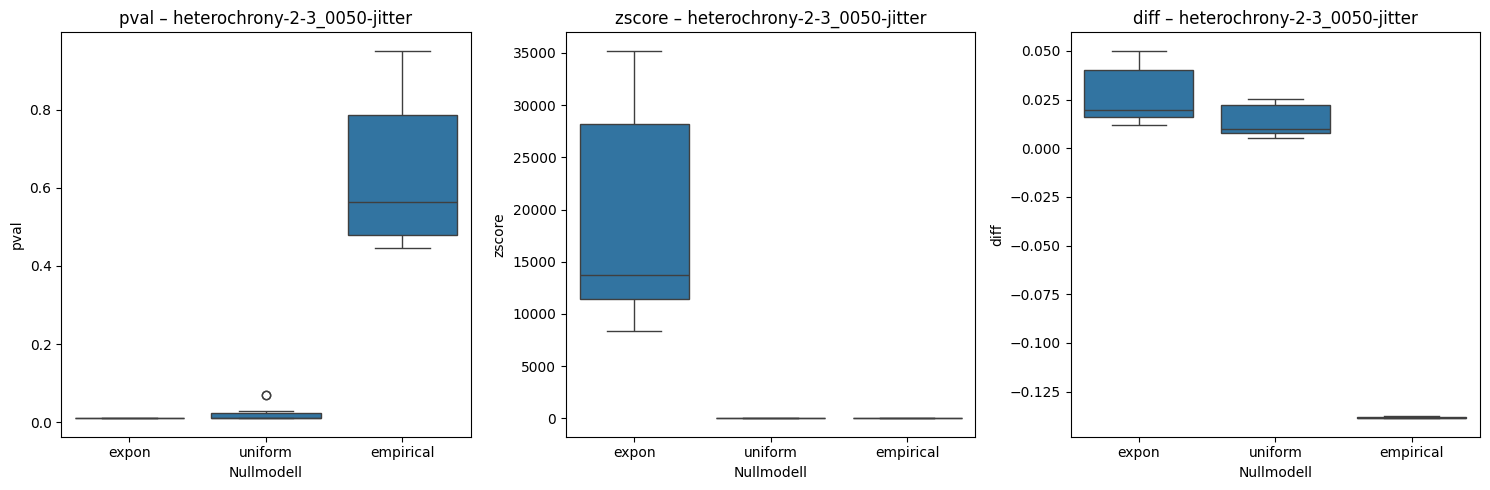

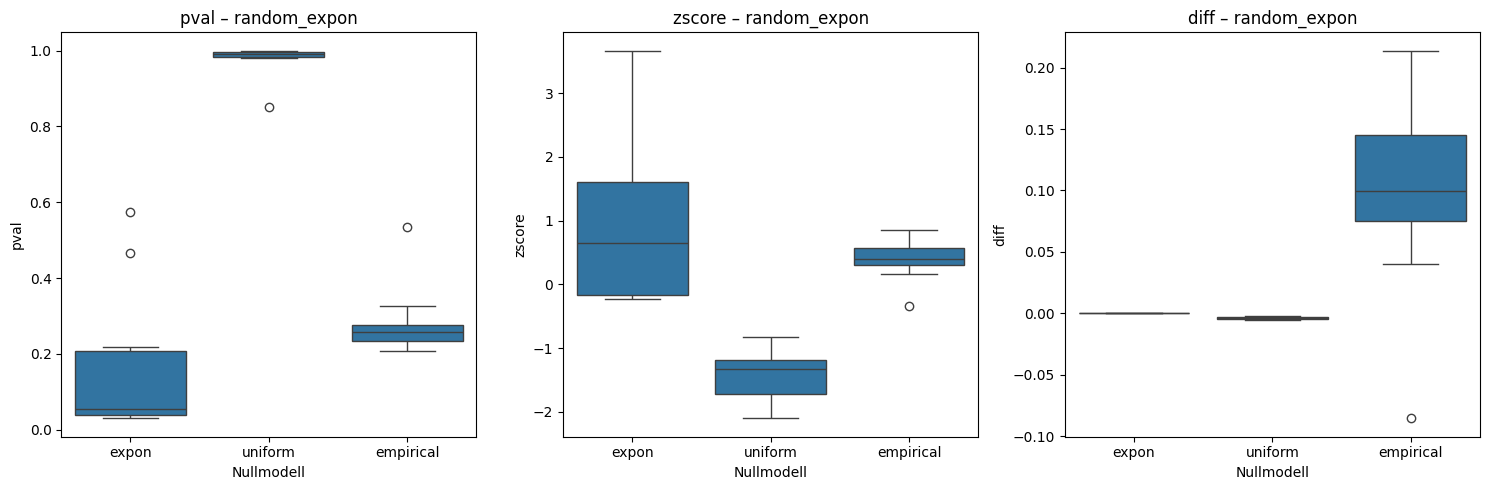

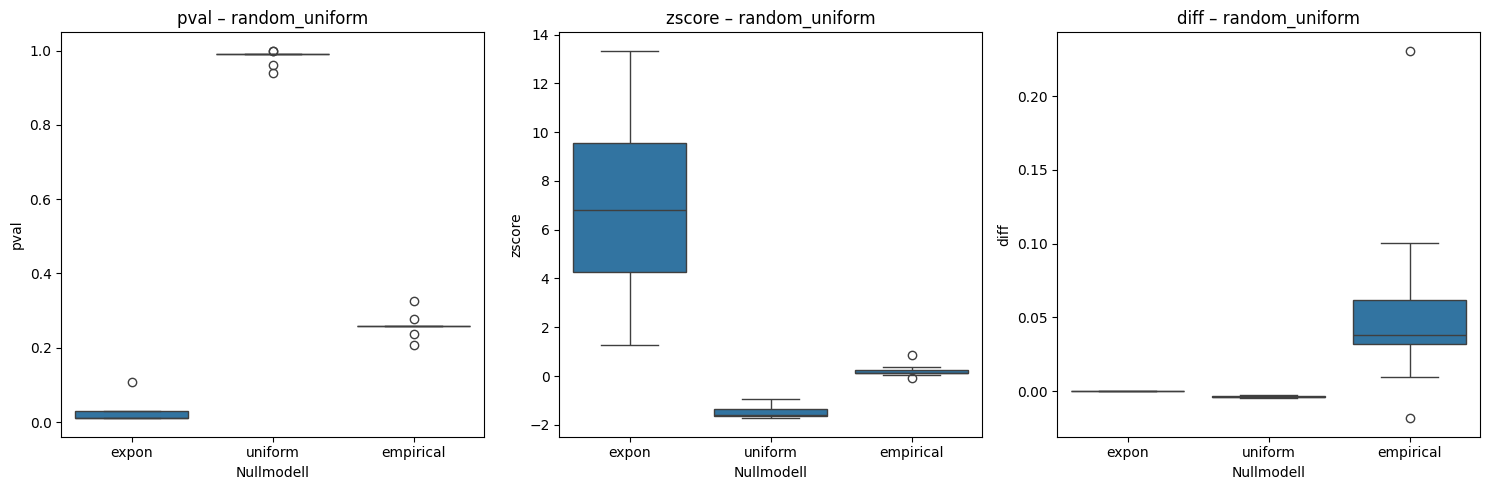

Sequenz-Level-Ergebnisse in 'seq_level_results.csv' gespeichert.


In [2]:
# neuer testtttt

# Bayesian Optimization mit globalen Nullmodellen aus Ordner mit counter
# Sucht nach der besten Parameterkombination für die Proximity-Funktion
# unter Verwendung von Bayesian Optimization.

import os
import numpy as np
import pandas as pd
from skopt import gp_minimize
from skopt.space import Real, Integer
import matplotlib.pyplot as plt
import seaborn as sns
import time

# ================================
# Proximity-Funktion
# ================================

def proximity_max_freq(
    x,
    sharpness_base=10.0,
    sharpness_growth=2.0,
    decay=0.1,
    max_freq=4,
    weight_exponent=1.0,
    freq_sharpness_exp=1.0,
    norm_x=1.0,
    output_max=1.0
):
    x = np.array(x)
    freqs = np.arange(1, max_freq + 1)
    all_freq_values = []

    for freq in freqs:
        weight = 1.0 / (freq ** weight_exponent)
        freq_sharpness_base = sharpness_base * (freq ** freq_sharpness_exp)
        freq_sharpness_growth = sharpness_growth * (freq ** freq_sharpness_exp)

        sharpness = freq_sharpness_base * (x ** freq_sharpness_growth)
        cos_term = ((1 + np.cos(2 * np.pi * freq * x)) / 2) ** sharpness

        peak_sharpness = freq_sharpness_base * (norm_x ** freq_sharpness_growth)
        peak_value = ((1 + np.cos(2 * np.pi * freq * norm_x)) / 2) ** peak_sharpness
        peak_value = np.where(peak_value == 0, 1e-12, peak_value)

        denom = np.where(x == 0, 1e-12, x ** decay)
        val = weight * (cos_term / peak_value) / denom
        all_freq_values.append(val)

    all_freq_values = np.array(all_freq_values)
    proximity_max = np.max(all_freq_values, axis=0)

    max_at_norm_x = np.max([
        (1.0 / (freq ** weight_exponent)) * 1.0 / (norm_x ** decay)
        for freq in freqs
    ])
    proximity_max = proximity_max / max_at_norm_x * output_max
    return proximity_max

# ================================
# Folder-Analyse mit flexiblem Nullmodell-Caching (jetzt mit rohen Ratios)
# ================================
_already_printed_global_ioi = False

# Cache speichert rohe IOI-Ratios pro (n, model)
_null_cache_store = {"expon": {}, "uniform": {}, "empirical": {}}

def analyze_folder_global_null(folder_path, params, num_sequences=500, seed=42,
                               null_resample=False, null_cache_size=5000):
    global _already_printed_global_ioi
    rng = np.random.default_rng(seed)
    results_list = []

    # -----------------------------
    # 1) Alle IOIs laden und globale Parameter bestimmen
    # -----------------------------
    all_iois = []
    seqs = []

    for fname in os.listdir(folder_path):
        if not fname.endswith(".csv"):
            continue

        df = pd.read_csv(os.path.join(folder_path, fname))
        if "IOI" not in df.columns:
            continue

        iois = df["IOI"].dropna().values
        if len(iois) < 3:
            continue

        all_iois.extend(iois)
        seqs.append((fname, iois))

    all_iois = np.array(all_iois)
    global_median_ioi = np.median(all_iois)
    global_min = np.percentile(all_iois, 5)
    global_max = np.percentile(all_iois, 95)

    if not _already_printed_global_ioi:
        print(f"Global median IOI = {global_median_ioi:.3f}")
        print(f"Uniform bounds = [{global_min:.3f}, {global_max:.3f}]")
        _already_printed_global_ioi = True

    # -----------------------------
    # 2) Nullmodelle vorbereiten (nur rohe IOI-Ratios cachen!)
    # -----------------------------
    def build_null_ratios(n, model):
        ratios_list = []
        for _ in range(null_cache_size):
            if model == "expon":
                sim_iois = rng.exponential(scale=global_median_ioi, size=n)
            elif model == "uniform":
                sim_iois = rng.uniform(global_min, global_max, size=n)
            elif model == "empirical":
                sim_iois = rng.choice(all_iois, size=n, replace=True)
            # Ratios berechnen und speichern
            ratios = np.array([[max(sim_iois[i], sim_iois[j]) / min(sim_iois[i], sim_iois[j])
                                for j in range(n)] for i in range(n)])
            ratios_list.append(ratios)
        return ratios_list

    # Falls nicht vorhanden: neue Nullratios in Cache speichern
    for fname, iois in seqs:
        n = len(iois)
        for model in ["expon", "uniform", "empirical"]:
            if n not in _null_cache_store[model]:
                _null_cache_store[model][n] = build_null_ratios(n, model)

    # -----------------------------
    # 3) Analyse jeder Sequenz mit den Nullmodellen
    # -----------------------------
    for fname, iois in seqs:
        n = len(iois)
        # Realwerte
        ratios_real = np.array([[max(iois[i], iois[j]) / min(iois[i], iois[j])
                                 for j in range(n)] for i in range(n)])
        prox_mat_real = proximity_max_freq(ratios_real, **params)
        triu_idx = np.triu_indices_from(prox_mat_real, k=1)
        median_real = np.median(prox_mat_real[triu_idx])

        out = {"filename": fname, "real_median": median_real}

        for model in ["expon", "uniform", "empirical"]:
            all_ratios = _null_cache_store[model][n]
            if null_resample:
                chosen = rng.choice(len(all_ratios), size=num_sequences, replace=False)
            else:
                chosen = range(min(num_sequences, len(all_ratios)))
            medians = []
            for idx in chosen:
                prox_mat_null = proximity_max_freq(all_ratios[idx], **params)
                triu_idx = np.triu_indices_from(prox_mat_null, k=1)
                medians.append(np.median(prox_mat_null[triu_idx]))
            medians = np.array(medians)

            mean_val = np.mean(medians)
            std_val = np.std(medians, ddof=1)
            zscore_val = (median_real - mean_val) / std_val if std_val > 0 else np.nan
            pval_val = (np.sum(medians >= median_real) + 1) / (len(medians) + 1)

            out.update({
                f"{model}_mean": mean_val,
                f"{model}_std": std_val,
                f"diff_real_{model}": median_real - mean_val,
                f"zscore_{model}": zscore_val,
                f"pval_{model}": pval_val
            })

        results_list.append(out)

    return pd.DataFrame(results_list)

# ================================
# Bayesian Optimization
# ================================

def bayesian_search_global_null(
    folder_path,
    n_calls=100,
    num_sequences=500,
    seed=42,
    objective="zscore",   # one of: "diff", "zscore", "pval"
    null_model="expon",   # name used in analyze_folder columns for now: "expon", "uniform", "empirical"
    param_space_def=None,   # optional: override default param space dictionary (same keys as before)
    null_resample=False, 
    null_cache_size=5000
):
    """
    Bayesian search over the proximity-function parameter space.
    objective: "diff" (max), "zscore" (max), "pval" (min)
    null_model: string used to select columns returned by analyze_folder, e.g. "expon" -> diff_real_expon, zscore_expon, pval_expon
    Returns: summary_df (all evaluated params saved), best_params (according to chosen objective)
    """

    rng = np.random.default_rng(seed)
    default_params = {"norm_x": 1.0, "output_max": 1.0}

    # default parameter-space (same ranges as before)
    if param_space_def is None:
        param_space_def = {
            "sharpness_base": (1.0, 50.0),
            "sharpness_growth": (0.0, 5.0),
            "decay": (0.0, 4.0),
            "max_freq": (1, 6),  # integer
            "weight_exponent": (0.0, 4.0),
            "freq_sharpness_exp": (0.0, 4.0)
        }

    # build skopt space
    sk_space = [
        Real(param_space_def["sharpness_base"][0], param_space_def["sharpness_base"][1], name="sharpness_base"),
        Real(param_space_def["sharpness_growth"][0], param_space_def["sharpness_growth"][1], name="sharpness_growth"),
        Real(param_space_def["decay"][0], param_space_def["decay"][1], name="decay"),
        Integer(param_space_def["max_freq"][0], param_space_def["max_freq"][1], name="max_freq"),
        Real(param_space_def["weight_exponent"][0], param_space_def["weight_exponent"][1], name="weight_exponent"),
        Real(param_space_def["freq_sharpness_exp"][0], param_space_def["freq_sharpness_exp"][1], name="freq_sharpness_exp"),
    ]

    # will store intermediate results for post-hoc analysis
    eval_records = []
    call_counter = {"n": 0}
    timing_info = {"start": None}

    # objective function for gp_minimize (we minimize)
    def objective_func(x):
        call_counter["n"] += 1

        # Startzeit merken
        if timing_info["start"] is None:
            timing_info["start"] = time.time()

        # vergangene Zeit berechnen
        elapsed = time.time() - timing_info["start"]
        avg_time = elapsed / call_counter["n"]
        remaining = avg_time * (n_calls - call_counter["n"])
        eta_min = int(remaining // 60)
        eta_sec = int(remaining % 60)

        print(f"[Bayesian Optimization] Iteration {call_counter['n']} / {n_calls} "
            f"(ETA: {eta_min}m {eta_sec}s)")

        # map x to param dict
        names = ["sharpness_base", "sharpness_growth", "decay", "max_freq",
                "weight_exponent", "freq_sharpness_exp"]
        params = default_params.copy()
        params.update({n: v for n, v in zip(names, x)})
        params["max_freq"] = int(round(params["max_freq"]))

        # run analysis (this is the expensive call)
        results_df = analyze_folder_global_null(folder_path, params, num_sequences=num_sequences, seed=seed,
                               null_resample=False, null_cache_size=null_cache_size)

        if results_df.empty:
            return 1e6

        col_map = {
            "diff": f"diff_real_{null_model}",
            "zscore": f"zscore_{null_model}",
            "pval": f"pval_{null_model}"
        }
        col = col_map[objective]
        if col not in results_df.columns:
            return 1e5

        vals = results_df[col].dropna().values
        if len(vals) == 0:
            return 1e5

        if objective in ("diff", "zscore"):
            agg = np.median(vals)
            score = -float(agg)
        else:  # pval
            agg = np.median(vals)
            score = float(agg)

        eval_records.append({**params, f"agg_{objective}_{null_model}": float(agg)})

        return score

    # run Bayesian optimization
    res = gp_minimize(objective_func, sk_space, n_calls=n_calls, random_state=seed)

    # collect evaluated params into DataFrame
    summary_eval_df = pd.DataFrame(eval_records)

    # determine best set according to chosen objective
    agg_col_name = f"agg_{objective}_{null_model}"
    if agg_col_name in summary_eval_df.columns and not summary_eval_df.empty:
        if objective in ("diff", "zscore"):
            best_idx = summary_eval_df[agg_col_name].idxmax()
        else:  # pval
            best_idx = summary_eval_df[agg_col_name].idxmin()
        best_row = summary_eval_df.loc[best_idx]
    else:
        best_row = None

    return summary_eval_df, best_row, res

# ================================
# Optimierung + Sammeln der Sequenz-Werte
# ================================

def optimize_and_collect(folders, n_calls=30, num_sequences=50, seed=42, 
                         objective="pval", null_resample=False, null_cache_size=5000
    ):
    all_seq_results = []

    for folder in folders:
        for null_model in ["expon", "uniform", "empirical"]:
            print("==============================")
            print(f"Starte Optimierung: Folder={folder}, Nullmodell={null_model}, Objective={objective}")

            # 1. Bayesian Optimization laufen lassen
            summary_eval_df, best_row, res = bayesian_search_global_null(
                folder_path=folder,
                n_calls=n_calls,
                num_sequences=num_sequences,
                seed=seed,
                objective=objective,
                null_model=null_model,
                null_resample=null_resample, 
                null_cache_size=null_cache_size
            )

            if best_row is None:
                print("⚠️ Keine optimalen Parameter gefunden.")
                continue

            # 2. Beste Parameter extrahieren
            param_cols = ["sharpness_base","sharpness_growth","decay","max_freq","weight_exponent","freq_sharpness_exp"]
            best_params = {col: best_row[col] for col in param_cols}
            best_params.update({"norm_x":1.0, "output_max":1.0})

            print("Beste Parameterkombination:")
            print(best_params)

            # 3. Sequenzen mit besten Parametern analysieren
            df_seq = analyze_folder_global_null(
                folder_path=folder,
                params=best_params,
                num_sequences=num_sequences,
                seed=seed
            )

            if df_seq.empty:
                continue

            # 4. Werte pro Sequenz speichern
            for idx, row in df_seq.iterrows():
                record = {
                    "folder": folder.split("/")[-1],
                    "filename": row["filename"],
                    "null_model": null_model,
                    "pval": row[f"pval_{null_model}"],
                    "zscore": row[f"zscore_{null_model}"],
                    "diff": row[f"diff_real_{null_model}"]
                }
                # gefundene Parameter mit aufnehmen
                for p in param_cols:
                    record[p] = best_params[p]
                all_seq_results.append(record)

    return pd.DataFrame(all_seq_results)

# ================================
# Boxplots zeichnen
# ================================

def plot_all_boxplots(results_df, metrics=("pval","zscore","diff")):
    folders = results_df["folder"].unique()

    for folder in folders:
        subset = results_df[results_df["folder"] == folder]

        plt.figure(figsize=(15,5))
        for i, metric in enumerate(metrics, 1):
            plt.subplot(1, len(metrics), i)
            sns.boxplot(data=subset, x="null_model", y=metric, order=["expon","uniform","empirical"])
            plt.title(f"{metric} – {folder}")
            plt.xlabel("Nullmodell")
            plt.ylabel(metric)
        plt.tight_layout()
        plt.show()

# ================================
# Beispiel-Aufruf
# ================================
folders = [
    "/Users/emilschmiedl/Desktop/Proximity-Funktion/data/bayes_opti-testing/heterochrony-2-3_0050-jitter",
    "/Users/emilschmiedl/Desktop/Proximity-Funktion/data/bayes_opti-testing/random_expon",
    "/Users/emilschmiedl/Desktop/Proximity-Funktion/data/bayes_opti-testing/random_uniform"
]

seq_results_df = optimize_and_collect(folders, n_calls=30, num_sequences=100, seed=42, objective="pval", null_resample=False, null_cache_size=1000)

if not seq_results_df.empty:
    plot_all_boxplots(seq_results_df)
    seq_results_df.to_csv("seq_level_results.csv", index=False)
    print("Sequenz-Level-Ergebnisse in 'seq_level_results.csv' gespeichert.")


In [ ]:
# Auswertung der gespeicherten Sequenz-Level-Ergebnisse
import pandas as pd
import numpy as np

# Ergebnisse laden
dp = pd.read_csv("../code/seq_level_results.csv")

# Median p-Werte pro Ordner und Nullmodell
median_pvals = dp.groupby(["folder","null_model"])["pval"].median().unstack()
print("Median p-Werte pro Ordner und Nullmodell:\n")
print(median_pvals)

max_pvals = dp.groupby(["folder","null_model"])["pval"].max().unstack()
print("\nHöchster p-Wert pro Ordner und Nullmodell:\n")
print(max_pvals)

# Zähler für signifikante und alle Sequenzen
sig_counts = dp[dp["pval"] < 0.05].groupby(["folder","null_model"])["filename"].count()
total_counts = dp.groupby(["folder","null_model"])["filename"].count()

# beides kombinieren
summary = (sig_counts.astype(str) + " von " + total_counts.astype(str)).unstack(fill_value="0 von 0")

print("\nAnzahl signifikante Sequenzen (p < 0.05) pro Ordner und Nullmodell:\n")
print(summary)


Median p-Werte pro Ordner und Nullmodell:

null_model                            empirical     expon   uniform
folder                                                             
Bat Carollia perspicillata (C_persp)   0.139303  0.009950  0.049751
Kwa-Sounds Scorpaena spp               0.057214  0.014925  0.057214

Höchster p-Wert pro Ordner und Nullmodell:

null_model                            empirical     expon   uniform
folder                                                             
Bat Carollia perspicillata (C_persp)   1.000000  0.661692  1.000000
Kwa-Sounds Scorpaena spp               0.741294  0.417910  0.706468

Anzahl signifikante Sequenzen (p < 0.05) pro Ordner und Nullmodell:

null_model                            empirical      expon    uniform
folder                                                               
Bat Carollia perspicillata (C_persp)  15 von 47  28 von 47  25 von 47
Kwa-Sounds Scorpaena spp              10 von 20  13 von 20  10 von 20
